# Random Forest 

**Random Forest** is a **machine learning algorithm** that combines many **Decision Trees** to make a more accurate and reliable prediction.

Instead of relying on one decision tree, it creates a **"forest" of multiple trees** and combines their results.

### How it works

1. 🌳 Creates many **Decision Trees** using different random samples of the training data.
2. 🎲 Each tree also considers a random subset of features when making decisions.
3. 🗳️ For **classification**, each tree votes for a class, and the majority vote becomes the final prediction.
4. 📊 For **regression**, the predictions from all trees are typically averaged.

**Example:**

Suppose you're predicting whether an email is spam:

```text
Tree 1 → Spam
Tree 2 → Not Spam
Tree 3 → Spam
Tree 4 → Spam
Tree 5 → Spam

Final prediction → Spam ✅
```

### Why use Random Forest?

* More accurate than a single decision tree in many cases
* Reduces **overfitting**
* Works with many features
* Can be used for both **classification and regression**
* Usually doesn't require feature scaling

In one sentence:

> **Random Forest = Many Decision Trees + Randomness + Combined Prediction** 🌳🌳🌳


In [18]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [19]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [20]:
df = pd.DataFrame(X, columns=['col1','col2','col3','col4','col5'])
df['target']=y
print(df.shape)
df.sample(5)

(100, 6)


,col1,col2,col3,col4,col5,target
29,0.132716,-1.134314,-1.814857,-2.339791,-1.463127,1
56,-0.544047,0.384843,0.330327,-0.235635,1.798616,0
15,1.576969,1.864306,-3.811047,-4.759749,-1.720864,1
43,0.069283,-0.484086,-2.596758,-2.638793,-2.183466,1
74,-1.008080,-0.597860,-1.756093,-1.332269,-1.277058,1


In [21]:
# function of row sampling 

def sample_row(df, percent):
    return df.sample(int(percent*df.shape[0]), replace=True)

In [37]:
# function for feature sampling

def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [ ]:
# function for combined sampling

def combined_sampling(df, row_percent, col_percent):
    new_df = sample_row(df,row_percent)
    return sample_features(new_df, col_percent)

In [ ]:
# sample row
df1 = sample_row(df, 0.1)
df2 = sample_row(df, 0.1)
df3 = sample_row(df, 0.1)

In [23]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [25]:
clf1.fit(df1.iloc[:, 0:4], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, 0:4], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, 0:4], df3.iloc[:, -1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [27]:
from sklearn.tree import plot_tree

findfont: Failed to find font weight normal, now using 700.


[Text(0.5, 0.5, 'gini = 0.0\nsamples = 10\nvalue = 1.0')]

findfont: Failed to find font weight normal, now using 700.


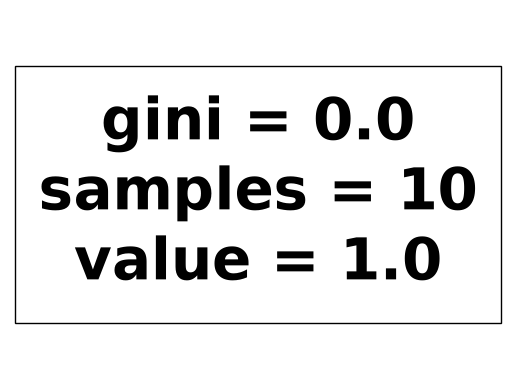

In [28]:
plot_tree(clf1)

[Text(0.6, 0.8333333333333334, 'x[2] <= 0.601\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.4, 0.5, 'x[0] <= -2.686\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

findfont: Failed to find font weight normal, now using 700.


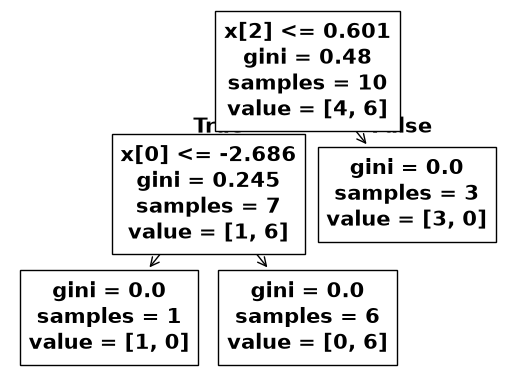

In [29]:
plot_tree(clf2)

[Text(0.6, 0.8333333333333334, 'x[2] <= -0.137\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.4, 0.5, 'x[3] <= -1.64\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

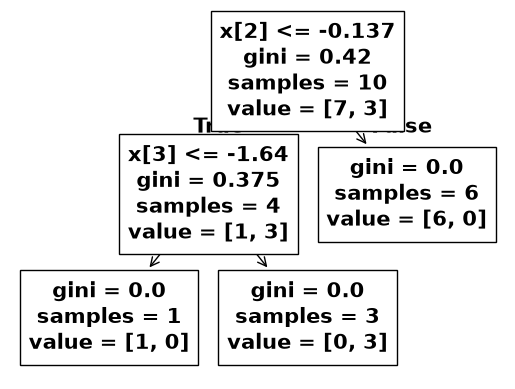

In [30]:
plot_tree(clf3)

In [33]:
clf1.predict(
    np.array([0.551350, -1.876815, -1.80716, -1.557932]).reshape(1, 4)
)

C:\Users\praja\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [34]:
clf1.predict(
    np.array([0.551350, -1.876815, -1.80716, -1.557932]).reshape(1, 4)
)

C:\Users\praja\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [36]:
clf1.predict(
    np.array([0.551350, -1.876815, -1.80716, -1.557932]).reshape(1, 4)
)

C:\Users\praja\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])